# Cross Tabulation

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('auto-mpg.csv')
pd.crosstab(df['cylinders'],df['model year'],rownames=['cylinders'],colnames=['model year'])

model year,70,71,72,73,74,75,76,77,78,79,80,81,82
cylinders,,,,,,,,,,,,,
3,0,0,1,1,0,0,0,1,0,0,1,0,0
4,7,13,14,11,15,12,15,14,17,12,25,21,28
5,0,0,0,0,0,0,0,0,1,1,1,0,0
6,4,8,0,8,7,12,10,5,12,6,2,7,3
8,18,7,13,20,5,6,9,8,6,10,0,1,0


# Data Cleaning


## missing values

In [3]:
import numpy as np

In [29]:
sales_data=pd.DataFrame({'name':['william','Emma','Sofia','Markus','Anika','Paul','Edward','Thomas','Ethan',np.nan,'Arun',np.nan],
                         'region':[np.nan,'north','east',np.nan,'west','west','south',np.nan,'west','east','south',np.nan],
                         'sales':[50000,52000,np.nan,np.nan,42000,72000,49000,np.nan,67000,65000,67000,np.nan],
                          'expenses':[42000,43000,np.nan,np.nan,38000,39000,42000,np.nan,39000,50000,45000,np.nan]})
sales_data

,name,region,sales,expenses
0,william,NaN,50000.0,42000.0
1,Emma,north,52000.0,43000.0
2,Sofia,east,NaN,NaN
3,Markus,NaN,NaN,NaN
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
7,Thomas,NaN,NaN,NaN
8,Ethan,west,67000.0,39000.0
9,NaN,east,65000.0,50000.0


1. Delete complete row with nan. It will delete all the data of row
2. fill will dummy data
3. replace with mean,median values

In [10]:
sales_data.isna().sum()

name        1
region      3
sales       3
expenses    3
dtype: int64

Thresh: Thresh removes the invalid(nul/nan) data

In [13]:
sales_data.dropna()

,name,region,sales,expenses
1,Emma,north,52000.0,43000.0
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
8,Ethan,west,67000.0,39000.0
10,Arun,south,67000.0,45000.0


In [14]:
sales_data.dropna(thresh=2)

,name,region,sales,expenses
0,william,NaN,50000.0,42000.0
1,Emma,north,52000.0,43000.0
2,Sofia,east,NaN,NaN
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
8,Ethan,west,67000.0,39000.0
9,NaN,east,65000.0,50000.0
10,Arun,south,67000.0,45000.0


In [15]:
sales_data.dropna(thresh=3)

,name,region,sales,expenses
0,william,NaN,50000.0,42000.0
1,Emma,north,52000.0,43000.0
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
8,Ethan,west,67000.0,39000.0
9,NaN,east,65000.0,50000.0
10,Arun,south,67000.0,45000.0


In [16]:
sales_data.dropna(thresh=4)

,name,region,sales,expenses
1,Emma,north,52000.0,43000.0
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
8,Ethan,west,67000.0,39000.0
10,Arun,south,67000.0,45000.0


In [23]:
sales_data.dropna(how='any') #will remove the row having atleast one nan

,name,region,sales,expenses
1,Emma,north,52000.0,43000.0
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
8,Ethan,west,67000.0,39000.0
10,Arun,south,67000.0,45000.0


In [22]:
sales_data.dropna(how='all') #will remove a row having all the nan

,name,region,sales,expenses
0,william,NaN,50000.0,42000.0
1,Emma,north,52000.0,43000.0
2,Sofia,east,NaN,NaN
3,Markus,NaN,NaN,NaN
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
7,Thomas,NaN,NaN,NaN
8,Ethan,west,67000.0,39000.0
9,NaN,east,65000.0,50000.0


In [24]:
sales_data.dropna(subset=['sales','expenses'] #if sales or expenses has any nan that row will be removed 

,name,region,sales,expenses
0,william,NaN,50000.0,42000.0
1,Emma,north,52000.0,43000.0
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
8,Ethan,west,67000.0,39000.0
9,NaN,east,65000.0,50000.0
10,Arun,south,67000.0,45000.0


In [25]:
sales_data.dropna(axis=0) #rows having null values

,name,region,sales,expenses
1,Emma,north,52000.0,43000.0
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
8,Ethan,west,67000.0,39000.0
10,Arun,south,67000.0,45000.0


In [26]:
sales_data.dropna(axis=1) #columns having null values

""
0
1
2
3
4
5
6
7
8
9


In [27]:
sales_data.dropna(inplace=True)

In [30]:
sales_data.fillna(0) #will fill all the null/nan values with 0

,name,region,sales,expenses
0,william,0,50000.0,42000.0
1,Emma,north,52000.0,43000.0
2,Sofia,east,0.0,0.0
3,Markus,0,0.0,0.0
4,Anika,west,42000.0,38000.0
5,Paul,west,72000.0,39000.0
6,Edward,south,49000.0,42000.0
7,Thomas,0,0.0,0.0
8,Ethan,west,67000.0,39000.0
9,0,east,65000.0,50000.0


In [33]:
sales_data['sales'].fillna(sales_data['sales'].mean())

0     50000.0
1     52000.0
2     58000.0
3     58000.0
4     42000.0
5     72000.0
6     49000.0
7     58000.0
8     67000.0
9     65000.0
10    67000.0
11    58000.0
Name: sales, dtype: float64

In [35]:
sales_data['expenses'].fillna(sales_data['sales'].mean())

0     42000.0
1     43000.0
2     58000.0
3     58000.0
4     38000.0
5     39000.0
6     42000.0
7     58000.0
8     39000.0
9     50000.0
10    45000.0
11    58000.0
Name: expenses, dtype: float64

In [36]:
sales_data['expenses'].fillna(sales_data['sales'].median())

0     42000.0
1     43000.0
2     58500.0
3     58500.0
4     38000.0
5     39000.0
6     42000.0
7     58500.0
8     39000.0
9     50000.0
10    45000.0
11    58500.0
Name: expenses, dtype: float64

In [38]:
df=pd.read_csv('auto-mpg.csv')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [40]:
df=df[df['horsepower']!='?']
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [41]:
df=df[df['horsepower']=='?']
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name


In [42]:
df.drop('mpg',axis=1)

,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name


## Outliers


IQR-Inter Quartile Range


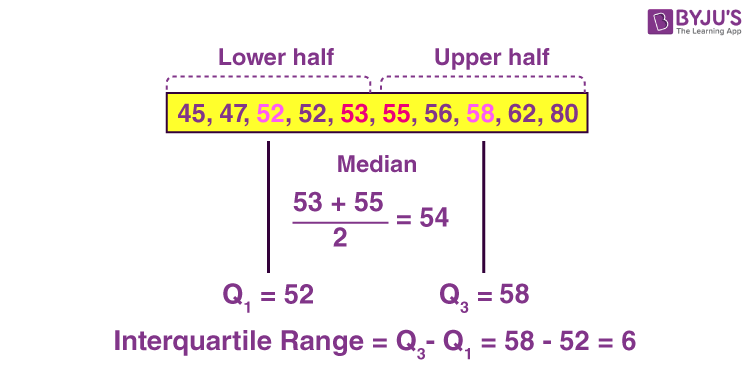

IQR=q3-q1=6


low_val=q1-1.5 * IQR=(52-1.5*6)=43


high_val=q3+1.5 * IQR=(58+9*6) =67

In [52]:
def find_outliers(ds,col):
    quart1=ds[col].quantile(0.25)
    quart3=ds[col].quantile(0.75)
    IQR=quart3-quart1
    low_val=quart1-1.5 * IQR
    high_val=quart3+1.5 * IQR
    print(low_val)
    print(high_val)
    ds=ds.loc[(ds[col]<low_val)|(ds[col]>high_val)]
    return ds

In [55]:
df=pd.read_csv('auto-mpg.csv')
find_outliers(df,'mpg')

0.25
46.25


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
322,46.6,4,86.0,65,2110,17.9,80,3,mazda glc


In [56]:
find_outliers(df,'acceleration')

8.800000000000008
22.199999999999992


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl
11,14.0,8,340.0,160,3609,8.0,70,1,plymouth 'cuda 340
59,23.0,4,97.0,54,2254,23.5,72,2,volkswagen type 3
195,29.0,4,85.0,52,2035,22.2,76,1,chevrolet chevette
299,27.2,4,141.0,71,3190,24.8,79,2,peugeot 504
300,23.9,8,260.0,90,3420,22.2,79,1,oldsmobile cutlass salon brougham
326,43.4,4,90.0,48,2335,23.7,80,2,vw dasher (diesel)
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup


In [58]:
def remove_outliers(ds,col):
    quart1=ds[col].quantile(0.25)
    quart3=ds[col].quantile(0.75)
    IQR=quart3-quart1
    low_val=quart1-1.5 * IQR
    high_val=quart3+1.5 * IQR
    print(low_val)
    print(high_val)
    ds=ds.loc[(ds[col]>=low_val)&(ds[col]<=high_val)]
    return ds

In [59]:
remove_outliers(df,'mpg')

0.25
46.25


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [60]:
remove_outliers(df,'acceleration')

8.800000000000008
22.199999999999992


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,151.0,90,2950,17.3,82,1,chevrolet camaro
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [63]:
df=df[df['horsepower']!='?']
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [64]:
df['horsepower']=df['horsepower'].astype('int64')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 30.6+ KB
